# 02 · Floating-point representation and rounding

**Time:** 100–120 minutes. **Prerequisites:** Lecture 01, powers of two.
**Lab:** [Inspect the machine](../labs/lab02_floating_point.ipynb).

Objectives: decode a binary64 number, predict its neighboring spacing, distinguish
machine epsilon from unit roundoff, explain normal/subnormal behavior, and audit
conversions among floats, rationals, and decimals.

## THEORY · A finite collection of numbers

A positive normal binary floating-point number with precision $p$ has the form

$$x=(1.b_1b_2\cdots b_{p-1})_2\,2^e.$$

Binary64 uses one sign bit, 11 exponent bits, and 52 stored fraction bits.
The implicit leading one gives **53 significant binary digits** for normal
numbers. The stored exponent is biased by 1023. Special exponent fields encode
subnormals, zero, infinities, and NaNs. We investigate this concrete format;
these numbers are not a uniform grid over the real line.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
import math
import struct
import sys
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from vc.environment import require_binary64

require_binary64()

def binary64_fields(x):
    bits = struct.unpack(">Q", struct.pack(">d", float(x)))[0]
    sign = bits >> 63
    exponent = (bits >> 52) & ((1 << 11) - 1)
    fraction = bits & ((1 << 52) - 1)
    return sign, exponent, fraction

for x in [1.0, 1.5, -2.5, 0.1]:
    sign, exponent, fraction = binary64_fields(x)
    print(f"{x:5g}: sign={sign}, stored exponent={exponent}, "
          f"fraction={fraction:052b}")
    print("  hexadecimal:", x.hex(), "exact ratio:", x.as_integer_ratio())

    1: sign=0, stored exponent=1023, fraction=0000000000000000000000000000000000000000000000000000
  hexadecimal: 0x1.0000000000000p+0 exact ratio: (1, 1)
  1.5: sign=0, stored exponent=1023, fraction=1000000000000000000000000000000000000000000000000000
  hexadecimal: 0x1.8000000000000p+0 exact ratio: (3, 2)
 -2.5: sign=1, stored exponent=1024, fraction=0100000000000000000000000000000000000000000000000000
  hexadecimal: -0x1.4000000000000p+1 exact ratio: (-5, 2)
  0.1: sign=0, stored exponent=1019, fraction=1001100110011001100110011001100110011001100110011010
  hexadecimal: 0x1.999999999999ap-4 exact ratio: (3602879701896397, 36028797018963968)


For 1.5 the significand is $1.1_2$ and the exponent is zero. For 0.1 the binary
expansion repeats forever, so finitely many bits cannot represent the intended
rational exactly. `float.hex()` describes the stored bits; a short decimal
display is chosen for convenient round-tripping, not to expose the full value.

**EXERCISE (5 minutes):** decode the sign, exponent, and fraction of -2.5 by hand.

## THEORY · Spacing inside a binade

A *binade* is $[2^e,2^{e+1})$. For normal numbers in it, increasing the last
significand bit changes the value by

$$\operatorname{spacing}=2^{e-(p-1)}.$$

**Proof.** The least significant stored bit has weight $2^{-(p-1)}$ in the
significand. Multiplying by $2^e$ gives the asserted step. The step doubles
on entering the next binade. At an exact power of two, the neighbor below is
in the previous binade, so its gap can differ from the gap above.

In [3]:
for x in [0.5, 1.0, 2.0, 2.0**52, 2.0**53]:
    down = math.nextafter(x, -math.inf)
    up = math.nextafter(x, math.inf)
    print(f"x={x:g}, gap below={x-down:g}, gap above={up-x:g}")

x=0.5, gap below=5.55112e-17, gap above=1.11022e-16
x=1, gap below=1.11022e-16, gap above=2.22045e-16
x=2, gap below=2.22045e-16, gap above=4.44089e-16
x=4.5036e+15, gap below=0.5, gap above=1
x=9.0072e+15, gap below=1, gap above=2


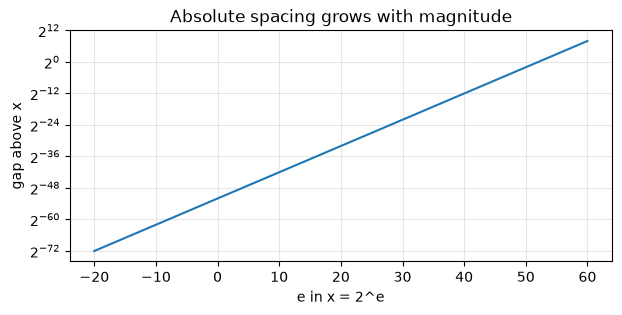

In [4]:
exponents = np.arange(-20, 61)
gaps = [math.nextafter(2.0**int(e), math.inf) - 2.0**int(e) for e in exponents]
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(exponents, gaps, base=2)
ax.set(xlabel="e in x = 2^e", ylabel="gap above x", title="Absolute spacing grows with magnitude")
ax.grid(alpha=0.3)
display(fig)
plt.close(fig)

## THEORY · Two constants with different names

In this course **machine epsilon** means the gap above 1:
$\varepsilon=2^{1-p}=2^{-52}$. **Unit roundoff** for round-to-nearest is
$u=2^{-p}=2^{-53}$. Literature sometimes uses “machine epsilon” for either;
always check the definition.

**Rounding bound.** For a real $x$ in the normal range, with no overflow,
rounding to nearest gives

$$\operatorname{fl}(x)=x(1+\delta),\qquad |\delta|\leq u.$$

**Proof sketch.** On the binade starting at $2^e$, nearest rounding moves a
value by at most half a spacing, $2^{e-p}$. Divide by $|x|\geq2^e$.
Symmetry handles negative values. Ties-to-even specifies which neighbor to
choose at an exact midpoint; it does not enlarge the bound.

This models one correctly rounded operation on its exact input operands.
It does not say that a whole program has relative error at most $u$.

In [5]:
epsilon = math.nextafter(1.0, math.inf) - 1.0
unit_roundoff = epsilon / 2
assert epsilon == sys.float_info.epsilon == 2.0**-52
print("epsilon:", epsilon, "unit roundoff:", unit_roundoff)
print("1 + u:", 1.0 + unit_roundoff)
print("1 + epsilon:", 1.0 + epsilon)
for n in range(51, 55):
    print(n, (2.0**n + 1.0) == 2.0**n)

epsilon: 2.220446049250313e-16 unit roundoff: 1.1102230246251565e-16
1 + u: 1.0
1 + epsilon: 1.0000000000000002
51 False
52 False
53 True
54 True


At $2^{53}$, the gap above is 2. Adding 1 lands exactly halfway between
representable values, and ties-to-even chooses $2^{53}$. The integer 1 was
represented exactly; this is an arithmetic rounding event, not input error.

**Checkpoint:** what is the gap *below* $2^{53}$? Why does subtracting 1 work?

## THEORY + EXPERIMENT · Subnormals and special values

The smallest positive normal binary64 number is $2^{-1022}$. Subnormals omit
the leading one and fill the interval toward zero with fixed step $2^{-1074}$.
They give gradual underflow, but the uniform relative bound above no longer
applies. An absolute error bound is more useful there.

In [6]:
smallest_normal = sys.float_info.min
smallest_positive = math.nextafter(0.0, math.inf)
print("Smallest normal:", smallest_normal.hex())
print("Smallest positive:", smallest_positive.hex())
assert Fraction.from_float(smallest_positive) == Fraction(1, 2**1074)
tiny_exact = Fraction(1, 2**1075)
tiny_rounded = float(tiny_exact)
relative_error = abs(Fraction.from_float(tiny_rounded) - tiny_exact) / tiny_exact
print("Half the smallest subnormal rounds to:", tiny_rounded)
print("Its exact relative error:", relative_error)
assert relative_error == 1

Smallest normal: 0x1.0000000000000p-1022
Smallest positive: 0x0.0000000000001p-1022
Half the smallest subnormal rounds to: 0.0
Its exact relative error: 1


Infinity and NaN are not large ordinary real numbers. NaN does not compare equal
to itself. Signed zeros compare equal, although the sign can affect operations.
Python and NumPy also expose some exceptional cases differently.

In [7]:
try:
    print(1.0 / 0.0)
except ZeroDivisionError:
    print("Python scalar division by zero raises ZeroDivisionError.")

with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
    print("NumPy +0 reciprocal:", np.float64(1) / np.float64(0.0))
    print("NumPy -0 reciprocal:", np.float64(1) / np.float64(-0.0))
    print("NumPy 0/0:", np.float64(0) / np.float64(0))
    print("NumPy overflow:", np.float64(1e308) * np.float64(1e308))
print("Zeros equal:", 0.0 == -0.0, "negative-zero sign:", math.copysign(1, -0.0))
print("NaN equals itself:", math.nan == math.nan)

Python scalar division by zero raises ZeroDivisionError.
NumPy +0 reciprocal: inf
NumPy -0 reciprocal: -inf
NumPy 0/0: nan
NumPy overflow: inf
Zeros equal: True negative-zero sign: -1.0
NaN equals itself: False


## EXPERIMENT · More precision does not restore the original input

Construct decimals from strings to express intended decimal values. Constructing
from a float instead expresses that already-rounded float exactly. Decimal
arithmetic has a precision context, and nonterminating results still round.

In [8]:
with localcontext() as decimal_context:
    decimal_context.prec = 60
    print("From string:", Decimal("0.1"))
    print("From float: ", Decimal(0.1))
    print("Difference: ", Decimal(0.1) - Decimal("0.1"))
    print("A rounded third:", Decimal(1) / Decimal(3))
assert Fraction(Decimal("0.1")) == Fraction(1, 10)

From string: 0.1
From float:  0.1000000000000000055511151231257827021181583404541015625
Difference:  5.5511151231257827021181583404541015625E-18
A rounded third: 0.333333333333333333333333333333333333333333333333333333333333


Increasing the context later changes future arithmetic, not the provenance of
existing inputs. High precision is valuable for exploration; it is not an error
bound by itself. Local contexts keep the experiment from changing later cells.

## EXPERIMENT · Time conversion: a model inspired by the Patriot case

The historical report describes integer tenths of seconds converted with limited
precision; the error grew with uptime. We use a **simplified fixed-point model**
with 23 fractional binary bits, not a reconstruction of the historical code.

If $c=1/10$ and $\widehat c$ is a truncated binary approximation, then converting
$N$ ticks by multiplication gives the exact model error

$$\Delta t=N(c-\widehat c).$$

We model this conversion with exact rational arithmetic, not repeated float
addition. The small per-tick bias is multiplied by a large tick count.

In [9]:
fraction_bits = 23
scale = 2**fraction_bits
exact_tick = Fraction(1, 10)
truncated_tick = Fraction(scale // 10, scale)
tick_error = exact_tick - truncated_tick
assert Fraction(0) <= tick_error < Fraction(1, scale)
for hours in [1, 8, 24, 100]:
    ticks = hours * 3600 * 10
    error = ticks * tick_error
    print(f"{hours:3} hours: exact error {error} seconds; approximately {float(error):.7f} s")

  1 hours: exact error 225/65536 seconds; approximately 0.0034332 s
  8 hours: exact error 225/8192 seconds; approximately 0.0274658 s
 24 hours: exact error 675/8192 seconds; approximately 0.0823975 s
100 hours: exact error 5625/16384 seconds; approximately 0.3433228 s


This gives about 0.3433 s at 100 hours, consistent with the scale tabulated in
[GAO Appendix II](https://www.gao.gov/assets/imtec-92-26.pdf). Numerical agreement
with that table does not establish that this model reproduces every implementation
detail. The lesson is to state and check the duration over which an error bound
remains acceptable. The model is about numerical conversion, not clock hardware drift.

**EXERCISE (10 minutes):** derive a bound on $\Delta t$ using only the number
of fractional bits. What changes under rounding to nearest? Which bound would
be appropriate if the input tick length itself were uncertain?

## Recap, limits, and reading

Binary64 has fixed relative precision across its normal range and varying absolute
spacing. Underflow and overflow need separate handling. Exact input conversion,
a rounding mode, and arithmetic precision are distinct choices.

**Exit ticket:** distinguish $\varepsilon$ and $u$; explain the lost-increment
threshold; identify one case where a relative error is undefined or unhelpful.

**Reading:** Tucker §§1.2–1.5 (especially §1.3.4 and the IEEE formats).
[Python floating-point tutorial](https://docs.python.org/3/tutorial/floatingpoint.html)
and [Decimal documentation](https://docs.python.org/3/library/decimal.html).
Next: [Lecture 03](03_stability.ipynb).